# ESC SPMe: Plot I, V, T, and SOC for all cells

Conclusions: Because the model overpredicts current, I also let it overpredict temperature as opposed to tuning Cp and h to fit the data. Using the lumped thermal model, we see that the effect of decomposition heating is minimal, which was expected. SEI decomposition is also the only decomp reaction contributing to heating which was expected.  

In [1]:
# need to restart jupyter server? kernal? whenever a change is made to the pybamm module? 
import sys
import os
sys.path.insert(0,os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__")))))
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
# sys.path.insert(1,r'C:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\venv\Lib\MiKTeX')
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
# os.chdir(sys.path[0] + '\..') # change our working directory to the root of the pybamm folder
import pybamm
print(pybamm.__path__[0])
import dfols
from scipy import integrate, signal, constants
# import matplotlib
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': 'Computer Modern',
    'font.sans-serif': ['Computer Modern'],
    'font.size': 9,
})
%matplotlib widget
# pybamm.set_logging_level("INFO")

# reset plt settings
# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault)
# pybamm.settings.max_smoothing = 'exact'

c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm


# Load data

In [2]:
Q_nom = 4.6
t_end = 15*60

def load_data(SOC_0, SOC_name):
    # load data import ESC data from file
    raw_data = pd.read_csv("ESC_"+  SOC_name + "SOC_full.csv")
    esc_start = raw_data[-raw_data['Current Shunt']>1].index[0]-1
    esc_end = raw_data[raw_data['Time (s)']>(raw_data['Time (s)'].loc[esc_start]+t_end)].index[0]
    T_amb = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
    data = raw_data[['Time (s)', 'Voltage (V)', 'Cell Temperature', 'Thermocouple_2','Current Shunt', 'Force', 'CO2 from CAN (ppm)']].loc[esc_start:esc_end].copy()
    data.loc[data['Cell Temperature']>140, 'Cell Temperature'] = None
    # data.interpolate(inplace=True)
    data['Current Shunt'] = -(data['Current Shunt'] - np.mean(raw_data['Current Shunt'][0:esc_start]))
    data['Time (s)'] = data['Time (s)'] - data['Time (s)'].loc[esc_start]
    print(np.mean(raw_data['Force'][raw_data['Force']>0][0:esc_start]))
    data['Force'] = (data['Force'])*9.81
    df_labels = ['t', 'V', 'Temp','T_tab','I', 'F', 'CO2']
    data.set_axis(df_labels, axis=1, inplace=True)
    data['I_C'] = data.I/Q_nom 
    AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600
    AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
    data['SOC']= SOC_0 - AhT_calculated/Q_nom # load data import ESC data from file
    if SOC_name =='100B':
        data['V'].iloc[(data.t[0:-1]>800) & (data.V>0.1)]  = None # remove voltage recovery on 100B
    T_amb_0 = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
    data.reset_index(drop=True, inplace=True)

    # display(raw_data)
    return data, T_amb_0

display(load_data(1, '100A')[0])
display(load_data(1, '100B')[0])
display(load_data(0.75, '75')[0])
display(load_data(0.5, '50')[0])

14.012017304188932


C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\1409404887.py:18: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\1409404887.py:20: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600


,t,V,Temp,T_tab,I,F,CO2,I_C,SOC
0,0.000,4.176052,24.111259,24.649755,0.020091,135.614645,499,0.004368,0.999301
1,0.100,1.564826,24.140908,24.669499,231.399794,136.217933,499,50.304303,0.997904
2,0.200,1.543099,24.121142,24.639882,231.423703,136.313189,499,50.309501,0.996508
3,0.300,1.521092,24.150790,24.639882,231.033186,136.789469,499,50.224606,0.995110
4,0.400,1.515830,24.121142,24.649755,231.893918,136.789469,499,50.411721,0.993709
...,...,...,...,...,...,...,...,...,...
8996,899.602,0.019834,69.558434,61.983263,1.347038,10.098965,493,0.292834,0.346521
8997,899.702,0.019834,69.548850,61.964070,1.358993,10.225974,493,0.295433,0.346512
8998,899.802,0.019754,69.568017,61.964070,1.474553,9.971957,493,0.320555,0.346504
8999,899.902,0.019874,69.548850,61.973666,1.339069,10.416486,493,0.291102,0.346496


10.707335251675392


C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\1409404887.py:18: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\1409404887.py:20: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600
C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\1409404887.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['V'].iloc[(data.t[0:-1]>800) & (data.V>0.1)]  = None # remove voltage recovery on 100B


...

C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\1409404887.py:18: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\1409404887.py:20: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600


,t,V,Temp,T_tab,I,F,CO2,I_C,SOC
0,0.000,3.907343,21.886238,22.831761,0.038310,138.377069,514,0.008328,0.749306
1,0.100,1.447498,21.965434,22.821872,229.836021,138.567582,514,49.964352,0.747927
2,0.200,1.408588,21.896138,22.841649,226.747750,139.107366,514,49.292989,0.746561
3,0.300,1.388854,21.866438,22.851538,225.799352,139.202622,514,49.086816,0.745201
4,0.400,1.379884,21.995131,22.900978,224.699529,139.361382,514,48.847724,0.743846
...,...,...,...,...,...,...,...,...,...
8996,899.607,0.016445,67.207862,60.956254,2.783855,79.096074,468,0.605186,0.175884
8997,899.707,0.016366,67.198277,60.937054,2.732052,78.905562,468,0.593924,0.175867
8998,899.807,0.016405,67.198277,60.937054,2.736037,79.191330,468,0.594791,0.175851
8999,899.907,0.016366,67.188692,60.908253,2.744007,78.873810,468,0.596523,0.175834


9.896317800676472


C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\1409404887.py:18: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\1409404887.py:20: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600


,t,V,Temp,T_tab,I,F,CO2,I_C,SOC
0,0.000,3.681772,20.717458,21.703908,0.013195,96.527925,487,0.002869,0.499317
1,0.100,1.704639,20.667907,22.188824,226.184678,96.591429,487,49.170582,0.497969
2,0.200,1.492907,20.737278,21.664314,220.187457,96.718437,487,47.866839,0.496642
3,0.300,1.472893,20.856188,21.733602,219.470182,97.194717,487,47.710909,0.495319
4,0.400,1.466116,20.737278,21.792990,218.792755,97.416981,487,47.563642,0.493998
...,...,...,...,...,...,...,...,...,...
8996,899.601,0.001934,47.394652,46.027554,0.379799,53.726221,478,0.082565,0.034287
8997,899.701,0.001894,47.394652,46.027554,0.300103,54.043741,475,0.065240,0.034285
8998,899.801,0.001934,47.394652,45.998501,0.339951,54.551773,475,0.073902,0.034283
8999,899.901,0.001854,47.433362,45.998501,0.527238,53.345197,475,0.114617,0.034280


In [3]:
SOC_names = ['100A', '100B', '75', '50']
SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}

datas = []
for SOC_name in SOC_names: 
    print(SOC_name)

    # load data and sim 
    SOC_0 = SOC_0s[SOC_name]
    data = load_data(SOC_0, SOC_name)[0]    
    datas.append(data)


100A


C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\1409404887.py:18: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\1409404887.py:20: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600
C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\1409404887.py:18: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\1409404887.py:20: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.int

14.012017304188932
100B
10.707335251675392
75
14.177060334002125
50


C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\1409404887.py:18: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\1409404887.py:20: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600


9.896317800676472


C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\1409404887.py:18: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\1409404887.py:20: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600


# Plot vs time

15.0682938738
11.4838451475
15.375229938600002
10.725325000630002


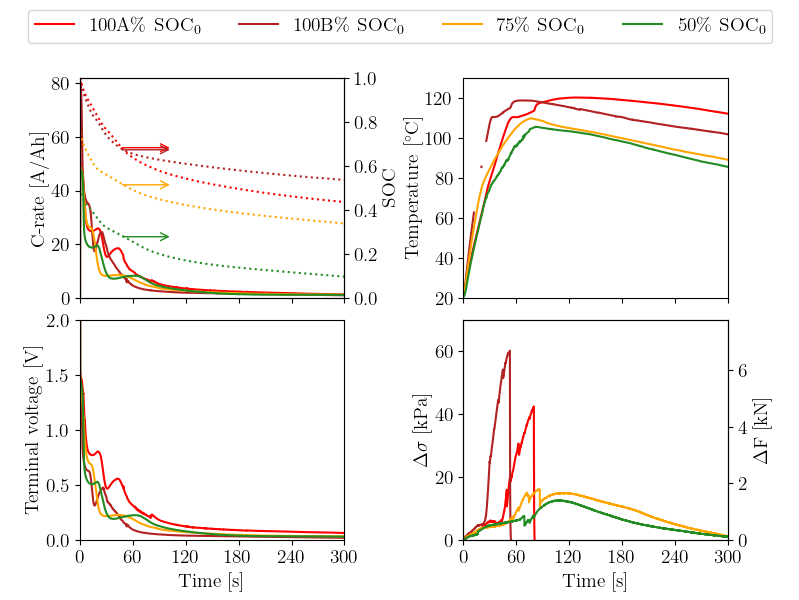

In [4]:
check_plot_SOC = True

plt.rcParams.update({
    'font.size': 14,
})

param = pybamm.ParameterValues('Tran2023')
# sim_set_labels = ['SPMeTV: Average', 'SPMeTV: Fit']
fig, ax = plt.subplots(2,  2, figsize=(13.333*0.6, 7.5*0.8), sharex=True)#, constrained_layout=True
plt.subplots_adjust(left=0.1, bottom=0.1, right=0.91, top=0.87, wspace=0.45, hspace=0.1)
linestyles = ['-','--','-.',':']*2
sim_colors = ['r','firebrick','orange','forestgreen']

# t_refs = [1, 1*60, 5*60]
# t_refs_labels = ['1 s', '1 min', '5 min']

# for each cell...
for i, (SOC_name,data) in enumerate(zip (SOC_names,datas)):    
    SOC_0 = SOC_0s[SOC_name]

    # plot
    xlabel = "Time [s]"
    data_color = sim_colors[i]
    data_ls = linestyles[0]

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000
    print(sigma_0)
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

    # LINEAR PLOTS
    ax[0,0].plot(data.t,data.I/Q_nom, label=SOC_name + "\% SOC$_0$",color = data_color, linestyle = data_ls)
    ax[0,0].set_ylabel('C-rate [A/Ah]', labelpad=2)
    # ax[0,0].set_title("Linear Time", size=9.5) #, pad = 30
    ax[0,0].set_ylim([0,82])
    # ax[0,0].set_xticklabels([])
    # ax[0,0].grid(color='0.8')
    if check_plot_SOC:
        if i ==0:
            ax_soc = ax[0,0].twinx()
        ax_soc.plot(data.t,data.SOC, linestyle= ':', color = data_color,label="__nolabel__")
        ax_soc.set_ylim([0,1])
        ax_soc.set_ylabel('SOC',labelpad=2)
        mid_idx = int(len(data)*0.05)
        ax_soc.annotate("",
                    xy=(data.t[mid_idx]+60, data.SOC[mid_idx]-0.01), xycoords='data',
                    xytext=(data.t[mid_idx], data.SOC[mid_idx]-0.01), textcoords='data',
                    arrowprops=dict(arrowstyle="->", connectionstyle="arc3", color=data_color))
    
    ax[1,0].plot(data.t, data.V,color = data_color, linestyle = data_ls)
    ax[1,0].set_ylabel('Terminal voltage [V]', labelpad=2)
    ax[1,0].set_ylim([0,2])
    ax[1,0].set_xlabel(xlabel) 
    # ax[1,0].grid(color='0.8')

    ax[0,1].plot(data.t, data.Temp,color = data_color, linestyle = data_ls)
    ax[0,1].set_ylabel('Temperature [$^\circ$C]',labelpad=2)
    ax[0,1].set_ylim([20,130])
    ax[0,1].set_yticks(np.arange(20,130,20))
    # ax[2,0].grid(color='0.8')

    # ax[2,0].plot(data.t, data.SOC,color = data_color, linestyle = data_ls)
    # ax[2,0].set_ylabel('SOC',labelpad=2)
    # ax[2,0].set_ylim([-0.03,1.03])
    # ax[2,0].grid(color='0.8')

    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    ax[1,1].plot(data.t, data_sigma, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[1,1].set_ylim([0,70])
    ax[1,1].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=2)
    ax[1,1].set_xlabel(xlabel) 
    if i ==0:
        ax_F=ax[1,1].twinx()
        ax_F.set_ylim([0,70/param["Active material surface area [m2]"]/1000])
        ax_F.set_ylabel('$\Delta$F [kN]')
    # ax[3,0].grid(color='0.8')

    # # LOG PLOTS
    # ax[0,1].semilogx(data.t,data.I/Q_nom, label=SOC_name + "\% SOC$_0$",color = data_color, linestyle = data_ls)
    # ax[0,1].set_ylabel('C-rate [A/Ah]', labelpad=0)
    # ax[0,1].set_title("Log Time", size=9.5) #, pad = 30
    # ax[0,1].set_ylim([0,82])
    # # ax[0,1].grid(color='0.8')
    # # ax[0,1].set_yticklabels([])
    # if check_plot_SOC:
    #     if i ==0:
    #         ax_soc_log = ax[0,1].twinx()
    #     ax_soc_log.semilogx(data.t,data.SOC, linestyle= ':', color = data_color,label="__nolabel__")
    #     ax_soc_log.set_ylim([0,1])
    #     ax_soc_log.set_ylabel('SOC') #, labelpad=0
    #     mid_idx = int(len(data)*0.2)
    #     ax_soc_log.annotate("",
    #                 xy=(data.t[mid_idx]+120*1.5, data.SOC[mid_idx]-0.01), xycoords='data',
    #                 xytext=(data.t[mid_idx], data.SOC[mid_idx]-0.01), textcoords='data',
    #                 arrowprops=dict(arrowstyle="->", connectionstyle="arc3", color=data_color))
    
    # ax[1,1].semilogx(data.t, data.V,color = data_color, linestyle = data_ls)
    # ax[1,1].set_ylabel('Terminal voltage [V]', labelpad=0)
    # ax[1,1].set_ylim([0,2])
    # # ax[1,1].grid(color='0.8')
    # # ax[1,1].set_yticklabels([])

    # ax[2,1].semilogx(data.t, data.Temp,color = data_color, linestyle = data_ls)
    # ax[2,1].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    # ax[2,1].set_ylim([20,130])
    # ax[2,1].set_yticks(np.arange(20,130,20))
    # # ax[2,1].grid(color='0.8')
    # # ax[2,1].set_yticklabels([])

    # # ax[2,1].semilogx(data.t, data.SOC,color = data_color, linestyle = data_ls)
    # # ax[2,1].set_ylabel('SOC',labelpad=0)
    # # ax[2,1].set_ylim([-0.03,1.03])
    # # ax[2,1].grid(color='0.8')
    # # ax[2,1].set_yticklabels([])

    # sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    # ax[3,1].semilogx(data.t, data_sigma, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    # ax[3,1].set_ylim([0,70])
    # ax[3,1].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    # ax[3,1].set_xlabel(xlabel)
    # if i ==0:
    #     ax_F_log=ax[3,1].twinx()
    #     ax_F_log.set_ylim([0,70/param["Active material surface area [m2]"]/1000])
    #     ax_F_log.set_ylabel('$\Delta$F [kN]')
    # # ax[3,1].grid(color='0.8')
    # # ax[3,1].set_yticklabels([])

# for axs in fig.get_axes():
#     # axs.set_xlim([0,data.t.iloc[-1]])
#     


plt.setp(ax, xticks=list(range(0,60*5+1,60)))
# plt.setp(ax[0:1, 1], xticks=[1e-1, 1,10,100, 1000])
handles, labels = ax[0,0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='upper center', ncol=len(SOC_names), bbox_to_anchor=(0.5, 1))
plt.xlim([0,60*5])
# plt.tight_layout()
plt.savefig('./figs/all_ESC_data_wide_with_SOC.jpg', format='jpg', dpi = 300)
plt.show()
plt.rcParams.update({
    'font.size': 9,
})


15.0682938738
11.4838451475
15.375229938600002
10.725325000630002


C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\4259861290.py:124: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axs.set_xlim([0,data.t.iloc[-1]])
C:\Users\Vivian\AppData\Local\Temp\ipykernel_39104\4259861290.py:132: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0,t_end])
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


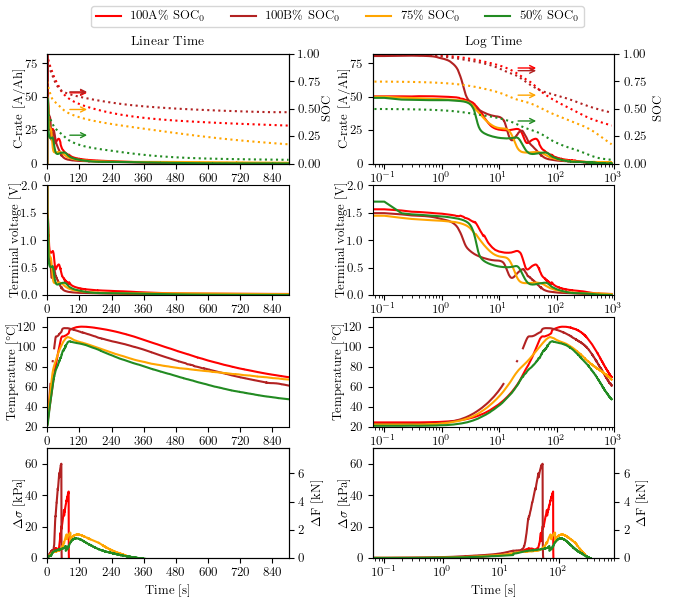

In [32]:
check_plot_SOC = True


param = pybamm.ParameterValues('Tran2023')
# sim_set_labels = ['SPMeTV: Average', 'SPMeTV: Fit']
fig, ax = plt.subplots(4,  2, figsize=(6.75, 6))#, constrained_layout=True
plt.subplots_adjust(left=0.07, bottom=0.07, right=0.91, top=0.91, wspace=0.35, hspace=0.2)
linestyles = ['-','--','-.',':']*2
sim_colors = ['r','firebrick','orange','forestgreen']

# t_refs = [1, 1*60, 5*60]
# t_refs_labels = ['1 s', '1 min', '5 min']

# for each cell...
for i, (SOC_name,data) in enumerate(zip (SOC_names,datas)):    
    SOC_0 = SOC_0s[SOC_name]

    # plot
    xlabel = "Time [s]"
    data_color = sim_colors[i]
    data_ls = linestyles[0]

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000
    print(sigma_0)
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

    # LINEAR PLOTS
    ax[0,0].plot(data.t,data.I/Q_nom, label=SOC_name + "\% SOC$_0$",color = data_color, linestyle = data_ls)
    ax[0,0].set_ylabel('C-rate [A/Ah]', labelpad=0)
    ax[0,0].set_title("Linear Time", size=9.5) #, pad = 30
    ax[0,0].set_ylim([0,82])
    # ax[0,0].set_xticklabels([])
    # ax[0,0].grid(color='0.8')
    if check_plot_SOC:
        if i ==0:
            ax_soc = ax[0,0].twinx()
        ax_soc.plot(data.t,data.SOC, linestyle= ':', color = data_color,label="__nolabel__")
        ax_soc.set_ylim([0,1])
        ax_soc.set_ylabel('SOC',labelpad=0)
        mid_idx = int(len(data)*0.06)
        ax_soc.annotate("",
                    xy=(data.t[mid_idx]+85+20, data.SOC[mid_idx]-0.01), xycoords='data',
                    xytext=(data.t[mid_idx]+20, data.SOC[mid_idx]-0.01), textcoords='data',
                    arrowprops=dict(arrowstyle="->", connectionstyle="arc3", color=data_color))
    
    ax[1,0].plot(data.t, data.V,color = data_color, linestyle = data_ls)
    ax[1,0].set_ylabel('Terminal voltage [V]', labelpad=0)
    ax[1,0].set_ylim([0,2])
    # ax[1,0].grid(color='0.8')

    ax[2,0].plot(data.t, data.Temp,color = data_color, linestyle = data_ls)
    ax[2,0].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    ax[2,0].set_ylim([20,130])
    ax[2,0].set_yticks(np.arange(20,130,20))
    # ax[2,0].grid(color='0.8')

    # ax[2,0].plot(data.t, data.SOC,color = data_color, linestyle = data_ls)
    # ax[2,0].set_ylabel('SOC',labelpad=2)
    # ax[2,0].set_ylim([-0.03,1.03])
    # ax[2,0].grid(color='0.8')

    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    ax[3,0].plot(data.t, data_sigma, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[3,0].set_ylim([0,70])
    ax[3,0].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[3,0].set_xlabel(xlabel) 
    if i ==0:
        ax_F=ax[3,0].twinx()
        ax_F.set_ylim([0,70/param["Active material surface area [m2]"]/1000])
        ax_F.set_ylabel('$\Delta$F [kN]')
    # ax[3,0].grid(color='0.8')

    # LOG PLOTS
    ax[0,1].semilogx(data.t,data.I/Q_nom, label=SOC_name + "\% SOC$_0$",color = data_color, linestyle = data_ls)
    ax[0,1].set_ylabel('C-rate [A/Ah]', labelpad=0)
    ax[0,1].set_title("Log Time", size=9.5) #, pad = 30
    ax[0,1].set_ylim([0,82])
    # ax[0,1].grid(color='0.8')
    # ax[0,1].set_yticklabels([])
    if check_plot_SOC:
        if i ==0:
            ax_soc_log = ax[0,1].twinx()
        ax_soc_log.semilogx(data.t,data.SOC, linestyle= ':', color = data_color,label="__nolabel__")
        ax_soc_log.set_ylim([0,1])
        ax_soc_log.set_ylabel('SOC') #, labelpad=0
        mid_idx = int(len(data)*0.01)
        ax_soc_log.annotate("",
                    xy=(data.t[mid_idx]+40, data.SOC[mid_idx]-0.03), xycoords='data',
                    xytext=(data.t[mid_idx]+10, data.SOC[mid_idx]-0.03), textcoords='data',
                    arrowprops=dict(arrowstyle="->", connectionstyle="arc3", color=data_color))
    
    ax[1,1].semilogx(data.t, data.V,color = data_color, linestyle = data_ls)
    ax[1,1].set_ylabel('Terminal voltage [V]', labelpad=0)
    ax[1,1].set_ylim([0,2])
    # ax[1,1].grid(color='0.8')
    # ax[1,1].set_yticklabels([])

    ax[2,1].semilogx(data.t, data.Temp,color = data_color, linestyle = data_ls)
    ax[2,1].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    ax[2,1].set_ylim([20,130])
    ax[2,1].set_yticks(np.arange(20,130,20))
    # ax[2,1].grid(color='0.8')
    # ax[2,1].set_yticklabels([])

    # ax[2,1].semilogx(data.t, data.SOC,color = data_color, linestyle = data_ls)
    # ax[2,1].set_ylabel('SOC',labelpad=0)
    # ax[2,1].set_ylim([-0.03,1.03])
    # ax[2,1].grid(color='0.8')
    # ax[2,1].set_yticklabels([])

    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    ax[3,1].semilogx(data.t, data_sigma, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[3,1].set_ylim([0,70])
    ax[3,1].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[3,1].set_xlabel(xlabel)
    if i ==0:
        ax_F_log=ax[3,1].twinx()
        ax_F_log.set_ylim([0,70/param["Active material surface area [m2]"]/1000])
        ax_F_log.set_ylabel('$\Delta$F [kN]')
    # ax[3,1].grid(color='0.8')
    # ax[3,1].set_yticklabels([])

for axs in fig.get_axes():
    axs.set_xlim([0,data.t.iloc[-1]])


plt.setp(ax[0:5, 0], xticks=list(range(0,t_end,60*2)))
plt.setp(ax[0:5, 1], xticks=[1e-1, 1,10,100, 1000])
handles, labels = ax[0,1].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='upper center', ncol=len(SOC_names), bbox_to_anchor=(0.5, 1))
plt.xlim([0,t_end])
# plt.tight_layout()
plt.savefig('./figs/all_ESC_data_wide_with_SOC.eps', format='eps', dpi = 300)
plt.show()


135.6146448642
103.3546063275
138.3770694474
96.52792500567001


C:\Users\Vivian\AppData\Local\Temp\ipykernel_27312\2971403395.py:90: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axs.set_xlim([0,data.t.iloc[-1]])
C:\Users\Vivian\AppData\Local\Temp\ipykernel_27312\2971403395.py:98: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0,t_end])
C:\Users\Vivian\AppData\Local\Temp\ipykernel_27312\2971403395.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


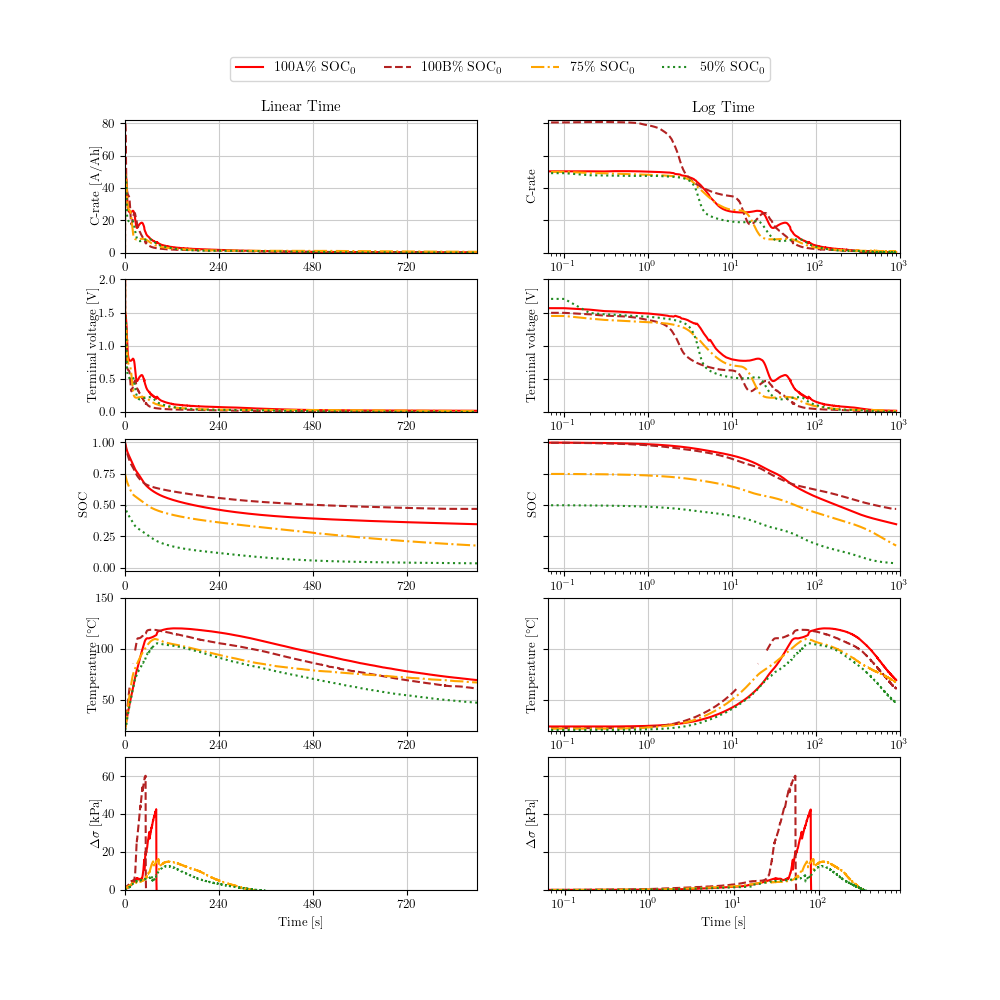

In [5]:
param = pybamm.ParameterValues('Tran2023')
# sim_set_labels = ['SPMeTV: Average', 'SPMeTV: Fit']
fig, ax = plt.subplots(5,  2, figsize=(10, 10), gridspec_kw = {'wspace':0.2, 'hspace':0.2}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['-','--','-.',':']*2
sim_colors = ['r','firebrick','orange','forestgreen']

# t_refs = [1, 1*60, 5*60]
# t_refs_labels = ['1 s', '1 min', '5 min']

# for each cell...
for i, (SOC_name,data) in enumerate(zip (SOC_names,datas)):    
    SOC_0 = SOC_0s[SOC_name]

    # plot
    xlabel = "Time [s]"
    data_color = sim_colors[i]
    data_ls = linestyles[i]

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000
    print(data['F'].iloc[0])
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

    # LINEAR PLOTS
    
    ax[0,0].plot(data.t,data.I/Q_nom, label=SOC_name + "\% SOC$_0$",color = data_color, linestyle = data_ls)
    ax[0,0].set_ylabel('C-rate [A/Ah]', labelpad=0)
    ax[0,0].set_title("Linear Time") #, pad = 30
    ax[0,0].set_ylim([0,82])
    # ax[0,0].set_xticklabels([])
    ax[0,0].grid(color='0.8')
    
    ax[1,0].plot(data.t, data.V,color = data_color, linestyle = data_ls)
    ax[1,0].set_ylabel('Terminal voltage [V]', labelpad=0)
    ax[1,0].set_ylim([0,2])
    ax[1,0].grid(color='0.8')

    ax[3,0].plot(data.t, data.Temp,color = data_color, linestyle = data_ls)
    ax[3,0].set_ylabel('Temperature [$^\circ$C]',labelpad=-2)
    ax[3,0].set_ylim([20,150])
    ax[3,0].grid(color='0.8')

    ax[2,0].plot(data.t, data.SOC,color = data_color, linestyle = data_ls)
    ax[2,0].set_ylabel('SOC',labelpad=2)
    ax[2,0].set_ylim([-0.03,1.03])
    ax[2,0].grid(color='0.8')

    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    ax[4,0].plot(data.t, data_sigma, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[4,0].set_ylim([0,70])
    ax[4,0].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[4,0].set_xlabel(xlabel) 
    ax[4,0].grid(color='0.8')

    # LOG PLOTS
    ax[0,1].semilogx(data.t,data.I/Q_nom, label=SOC_name + "\% SOC$_0$",color = data_color, linestyle = data_ls)
    ax[0,1].set_ylabel('C-rate', labelpad=0)
    ax[0,1].set_title("Log Time") #, pad = 30
    ax[0,1].set_ylim([0,82])
    ax[0,1].grid(color='0.8')
    ax[0,1].set_yticklabels([])

    ax[1,1].semilogx(data.t, data.V,color = data_color, linestyle = data_ls)
    ax[1,1].set_ylabel('Terminal voltage [V]', labelpad=0)
    ax[1,1].set_ylim([0,2])
    ax[1,1].grid(color='0.8')
    ax[1,1].set_yticklabels([])

    ax[3,1].semilogx(data.t, data.Temp,color = data_color, linestyle = data_ls)
    ax[3,1].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    ax[3,1].set_ylim([20,150])
    ax[3,1].grid(color='0.8')
    ax[3,1].set_yticklabels([])

    ax[2,1].semilogx(data.t, data.SOC,color = data_color, linestyle = data_ls)
    ax[2,1].set_ylabel('SOC',labelpad=0)
    ax[2,1].set_ylim([-0.03,1.03])
    ax[2,1].grid(color='0.8')
    ax[2,1].set_yticklabels([])

    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    ax[4,1].semilogx(data.t, data_sigma, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[4,1].set_ylim([0,70])
    ax[4,1].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[4,1].set_xlabel(xlabel)
    ax[4,1].grid(color='0.8')
    ax[4,1].set_yticklabels([])

for axs in fig.get_axes():
    axs.set_xlim([0,data.t.iloc[-1]])


plt.setp(ax[0:5, 0], xticks=list(range(0,t_end,60*4)))
plt.setp(ax[0:5, 1], xticks=[1e-1, 1,10,100, 1000])
handles, labels = ax[0,1].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='upper center', ncol=len(SOC_names), prop={'size': 10},  bbox_to_anchor=(0.5, 0.95))
plt.xlim([0,t_end])
plt.tight_layout()
plt.savefig('./figs/all_ESC_data_wide.eps', format='eps', dpi = 300)
plt.show()


C:\Users\Vivian\AppData\Local\Temp\ipykernel_27312\3764414201.py:89: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axs.set_xlim([0,data.t.iloc[-1]])
C:\Users\Vivian\AppData\Local\Temp\ipykernel_27312\3764414201.py:97: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0,t_end])
C:\Users\Vivian\AppData\Local\Temp\ipykernel_27312\3764414201.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


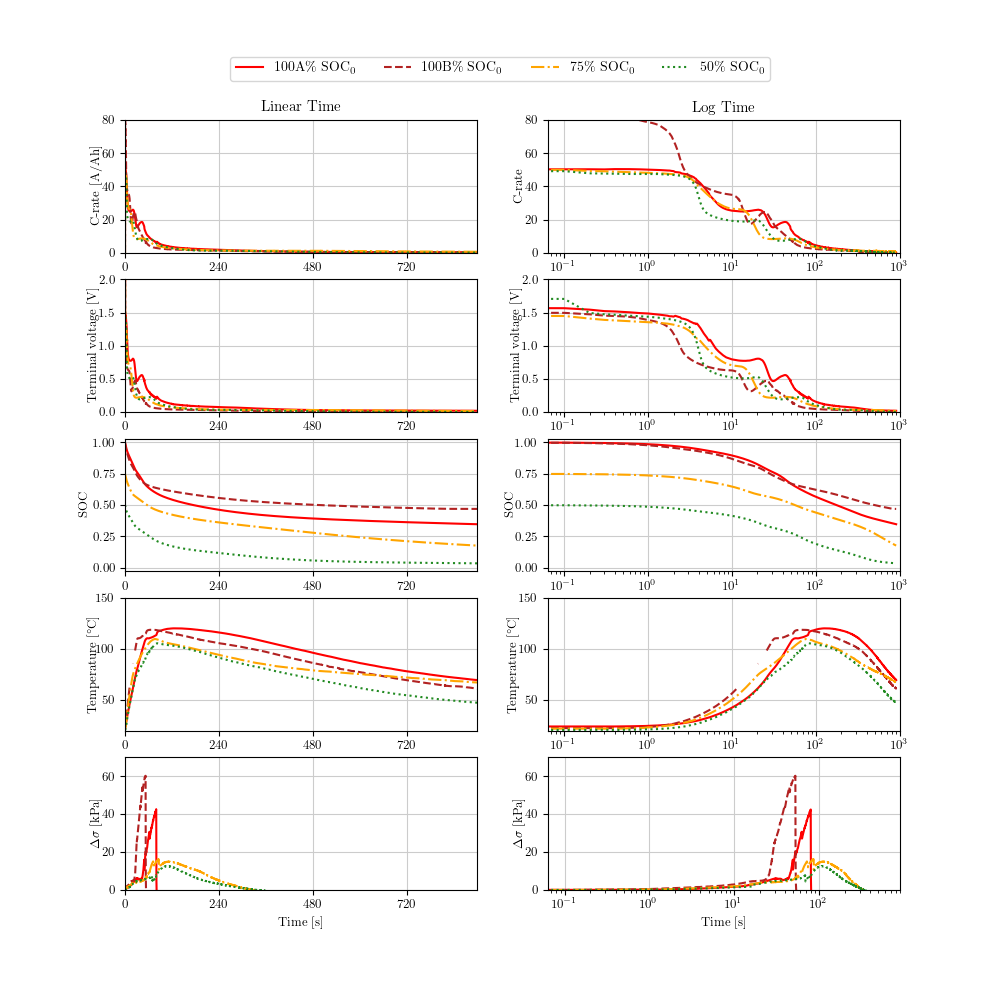

In [6]:
param = pybamm.ParameterValues('Tran2023')
# sim_set_labels = ['SPMeTV: Average', 'SPMeTV: Fit']
fig, ax = plt.subplots(5,  2, figsize=(10, 10), gridspec_kw = {'wspace':0.2, 'hspace':0.2}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['-','--','-.',':']*2
sim_colors = ['r','firebrick','orange','forestgreen']

# t_refs = [1, 1*60, 5*60]
# t_refs_labels = ['1 s', '1 min', '5 min']

# for each cell...
for i, (SOC_name,data) in enumerate(zip (SOC_names,datas)):    
    SOC_0 = SOC_0s[SOC_name]

    # plot
    xlabel = "Time [s]"
    data_color = sim_colors[i]
    data_ls = linestyles[i]

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

    # LINEAR PLOTS
    
    ax[0,0].plot(data.t,data.I/Q_nom, label=SOC_name + "\% SOC$_0$",color = data_color, linestyle = data_ls)
    ax[0,0].set_ylabel('C-rate [A/Ah]', labelpad=0)
    ax[0,0].set_title("Linear Time") #, pad = 30
    ax[0,0].set_ylim([0,80])
    # ax[0,0].set_xticklabels([])
    ax[0,0].grid(color='0.8')
    
    ax[1,0].plot(data.t, data.V,color = data_color, linestyle = data_ls)
    ax[1,0].set_ylabel('Terminal voltage [V]', labelpad=0)
    ax[1,0].set_ylim([0,2])
    ax[1,0].grid(color='0.8')

    ax[3,0].plot(data.t, data.Temp,color = data_color, linestyle = data_ls)
    ax[3,0].set_ylabel('Temperature [$^\circ$C]',labelpad=-2)
    ax[3,0].set_ylim([20,150])
    ax[3,0].grid(color='0.8')

    ax[2,0].plot(data.t, data.SOC,color = data_color, linestyle = data_ls)
    ax[2,0].set_ylabel('SOC',labelpad=2)
    ax[2,0].set_ylim([-0.03,1.03])
    ax[2,0].grid(color='0.8')

    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    ax[4,0].plot(data.t, data_sigma, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[4,0].set_ylim([0,70])
    ax[4,0].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[4,0].set_xlabel(xlabel) 
    ax[4,0].grid(color='0.8')

    # LOG PLOTS
    ax[0,1].semilogx(data.t,data.I/Q_nom, label=SOC_name + "\% SOC$_0$",color = data_color, linestyle = data_ls)
    ax[0,1].set_ylabel('C-rate', labelpad=0)
    ax[0,1].set_title("Log Time") #, pad = 30
    ax[0,1].set_ylim([0,80])
    ax[0,1].grid(color='0.8')
    # ax[0,1].set_yticklabels([])

    ax[1,1].semilogx(data.t, data.V,color = data_color, linestyle = data_ls)
    ax[1,1].set_ylabel('Terminal voltage [V]', labelpad=0)
    ax[1,1].set_ylim([0,2])
    ax[1,1].grid(color='0.8')
    # ax[1,1].set_yticklabels([])

    ax[3,1].semilogx(data.t, data.Temp,color = data_color, linestyle = data_ls)
    ax[3,1].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    ax[3,1].set_ylim([20,150])
    ax[3,1].grid(color='0.8')
    # ax[3,1].set_yticklabels([])

    ax[2,1].semilogx(data.t, data.SOC,color = data_color, linestyle = data_ls)
    ax[2,1].set_ylabel('SOC',labelpad=0)
    ax[2,1].set_ylim([-0.03,1.03])
    ax[2,1].grid(color='0.8')
    # ax[2,1].set_yticklabels([])

    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    ax[4,1].semilogx(data.t, data_sigma, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[4,1].set_ylim([0,70])
    ax[4,1].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[4,1].set_xlabel(xlabel)
    ax[4,1].grid(color='0.8')
    # ax[4,1].set_yticklabels([])

for axs in fig.get_axes():
    axs.set_xlim([0,data.t.iloc[-1]])


plt.setp(ax[0:5, 0], xticks=list(range(0,t_end,60*4)))
plt.setp(ax[0:5, 1], xticks=[1e-1, 1,10,100, 1000])
handles, labels = ax[0,1].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='upper center', ncol=len(SOC_names), prop={'size': 10},  bbox_to_anchor=(0.5, 0.95))
plt.xlim([0,t_end])
plt.tight_layout()
plt.savefig('./figs/all_ESC_data_wide.eps', format='eps', dpi = 300)
plt.show()


C:\Users\Vivian\AppData\Local\Temp\ipykernel_27312\3913008603.py:105: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0,t_end])
C:\Users\Vivian\AppData\Local\Temp\ipykernel_27312\3913008603.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


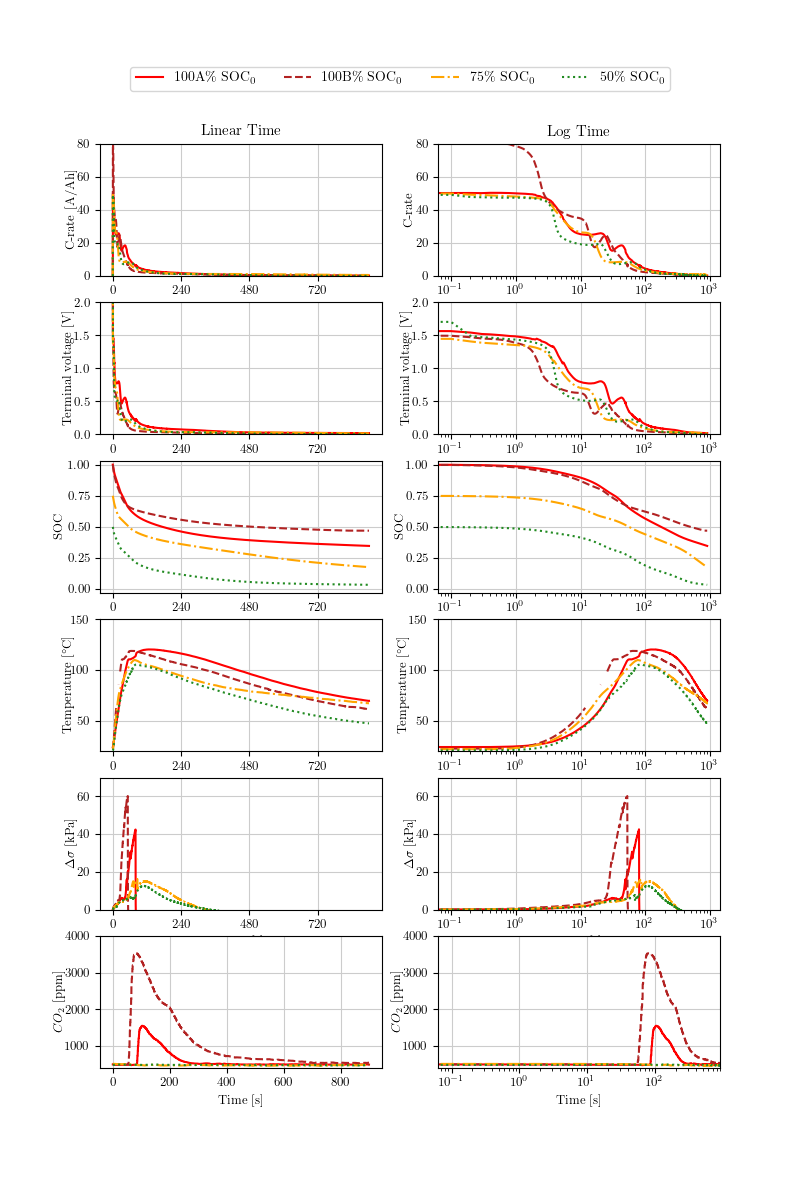

In [7]:
param = pybamm.ParameterValues('Tran2023')
# sim_set_labels = ['SPMeTV: Average', 'SPMeTV: Fit']
fig, ax = plt.subplots(6,  2, figsize=(8, 12), gridspec_kw = {'wspace':0.2, 'hspace':0.2}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['-','--','-.',':']*2
sim_colors = ['r','firebrick','orange','forestgreen']

# t_refs = [1, 1*60, 5*60]
# t_refs_labels = ['1 s', '1 min', '5 min']

# for each cell...
for i, (SOC_name,data) in enumerate(zip (SOC_names,datas)):    
    SOC_0 = SOC_0s[SOC_name]

    # plot
    xlabel = "Time [s]"
    data_color = sim_colors[i]
    data_ls = linestyles[i]

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

    # LINEAR PLOTS
    
    ax[0,0].plot(data.t,data.I/Q_nom, label=SOC_name + "\% SOC$_0$",color = data_color, linestyle = data_ls)
    ax[0,0].set_ylabel('C-rate [A/Ah]', labelpad=0)
    ax[0,0].set_title("Linear Time") #, pad = 30
    ax[0,0].set_ylim([0,80])
    # ax[0,0].set_xticklabels([])
    ax[0,0].grid(color='0.8')
    
    ax[1,0].plot(data.t, data.V,color = data_color, linestyle = data_ls)
    ax[1,0].set_ylabel('Terminal voltage [V]', labelpad=0)
    ax[1,0].set_ylim([0,2])
    ax[1,0].grid(color='0.8')

    ax[3,0].plot(data.t, data.Temp,color = data_color, linestyle = data_ls)
    ax[3,0].set_ylabel('Temperature [$^\circ$C]',labelpad=-2)
    ax[3,0].set_ylim([20,150])
    ax[3,0].grid(color='0.8')

    ax[2,0].plot(data.t, data.SOC,color = data_color, linestyle = data_ls)
    ax[2,0].set_ylabel('SOC',labelpad=2)
    ax[2,0].set_ylim([-0.03,1.03])
    ax[2,0].grid(color='0.8')

    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    ax[4,0].plot(data.t, data_sigma, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[4,0].set_ylim([0,70])
    ax[4,0].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[4,0].set_xlabel(xlabel) 
    ax[4,0].grid(color='0.8')

    ax[5,0].plot(data.t, data.CO2, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[5,0].set_ylabel("$CO_{2}$ [ppm]",labelpad=0)
    ax[5,0].set_ylim([400,4000])
    ax[5,0].set_xlabel(xlabel) 
    ax[5,0].grid(color='0.8')

    # LOG PLOTS
    ax[0,1].semilogx(data.t,data.I/Q_nom, label=SOC_name + "\% SOC$_0$",color = data_color, linestyle = data_ls)
    ax[0,1].set_ylabel('C-rate', labelpad=0)
    ax[0,1].set_title("Log Time") #, pad = 30
    ax[0,1].set_ylim([0,80])
    ax[0,1].grid(color='0.8')
    # ax[0,1].set_yticklabels([])

    ax[1,1].semilogx(data.t, data.V,color = data_color, linestyle = data_ls)
    ax[1,1].set_ylabel('Terminal voltage [V]', labelpad=0)
    ax[1,1].set_ylim([0,2])
    ax[1,1].grid(color='0.8')
    # ax[1,1].set_yticklabels([])

    ax[3,1].semilogx(data.t, data.Temp,color = data_color, linestyle = data_ls)
    ax[3,1].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    ax[3,1].set_ylim([20,150])
    ax[3,1].grid(color='0.8')
    # ax[3,1].set_yticklabels([])

    ax[2,1].semilogx(data.t, data.SOC,color = data_color, linestyle = data_ls)
    ax[2,1].set_ylabel('SOC',labelpad=0)
    ax[2,1].set_ylim([-0.03,1.03])
    ax[2,1].grid(color='0.8')
    # ax[2,1].set_yticklabels([])

    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    ax[4,1].semilogx(data.t, data_sigma, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[4,1].set_ylim([0,70])
    ax[4,1].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[4,1].set_xlabel(xlabel)
    ax[4,1].grid(color='0.8')
    # ax[4,1].set_yticklabels([])

    ax[5,1].semilogx(data.t, data.CO2, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[5,1].set_ylabel("$CO_{2}$ [ppm]",labelpad=0)
    ax[5,1].set_ylim([400,4000])
    ax[5,1].set_xlabel(xlabel) 
    ax[5,1].grid(color='0.8')

plt.setp(ax[0:5, 0], xticks=list(range(0,t_end,60*4)))
plt.setp(ax[0:5, 1], xticks=[1e-1, 1,10,100, 1000])
handles, labels = ax[0,1].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='upper center', ncol=4, prop={'size': 10},  bbox_to_anchor=(0.5, 0.95))
plt.xlim([0,t_end])
plt.tight_layout()
plt.savefig('./figs/all_ESC_data_wide_gas.eps', format='eps', dpi = 300)
plt.show()


C:\Users\Vivian\AppData\Local\Temp\ipykernel_27312\2243204747.py:157: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0,t_end])
C:\Users\Vivian\AppData\Local\Temp\ipykernel_27312\2243204747.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


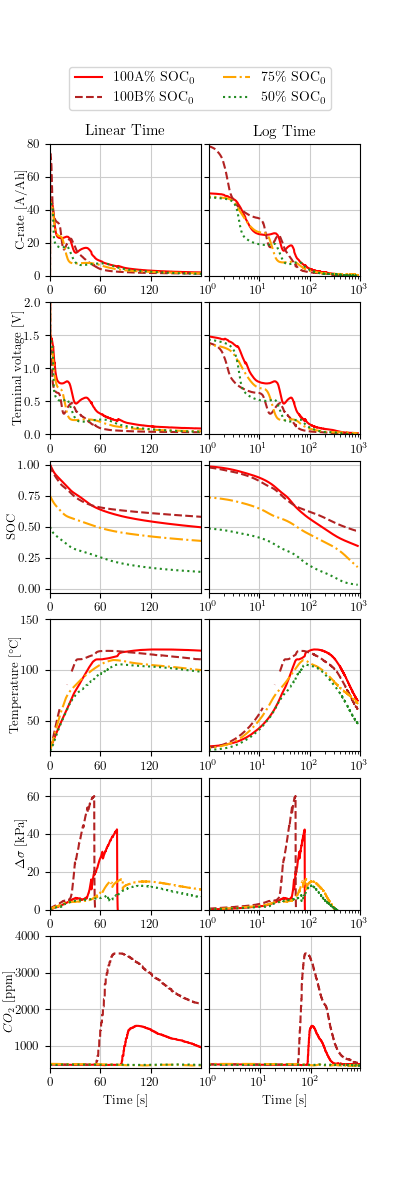

,SOC_0,SOC_f,DOD,T_max,sigma_maxs,I_0,Init_C-rate,V_0,T_tab_max,dT_max,t_vent
0,1.00,0.346496,0.653504,120.280990,42.463029,231.909857,50.415186,1.564826,114.673958,5.607032,79.8
1,1.00,0.468795,0.531205,118.821759,60.222997,371.526017,80.766525,1.494581,117.483086,1.338673,52.6
2,0.75,0.175834,0.574166,109.817425,16.179413,229.836021,49.964352,1.447498,103.279004,6.538421,-
3,0.50,0.034280,0.465720,105.569077,12.637299,226.184678,49.170582,1.704639,99.884402,5.684674,-


In [8]:
param = pybamm.ParameterValues('Tran2023')
sim_set_labels = ['SPMeTV: Average', 'SPMeTV: Fit']
fig, ax = plt.subplots(6,  2, figsize=(4, 12), gridspec_kw = {'wspace':0.05, 'hspace':0.2}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['-','--','-.',':']*2
sim_colors = ['r','firebrick','orange','forestgreen']

t_refs = [1, 1*60, 5*60]
t_refs_labels = ['1 s', '1 min', '5 min']

SOCs_0 = []
SOC_f = []
DOD = []
T_max = []
sigma_maxs = []
I_0 = []
V_0 = []
T_tab_max = []
t_vent = []

# for each cell...
for i, (SOC_name,data) in enumerate(zip (SOC_names,datas)):    
    SOC_0 = SOC_0s[SOC_name]

    # plot
    xlabel = "Time [s]"
    data_color = sim_colors[i]
    data_ls = linestyles[i]

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

    # LINEAR PLOTS
    
    ax[0,0].plot(data.t,data.I/param['Nominal cell capacity [A.h]'], label=SOC_name + "\% SOC$_0$",color = data_color, linestyle = data_ls)
    ax[0,0].set_ylabel('C-rate [A/Ah]', labelpad=0)
    ax[0,0].set_title("Linear Time") #, pad = 30
    ax[0,0].set_ylim([0,80])
    ax[0,0].set_xlim([0,60*3])
    # ax[0,0].set_xticklabels([])
    ax[0,0].grid(color='0.8')
    
    ax[1,0].plot(data.t, data.V,color = data_color, linestyle = data_ls)
    ax[1,0].set_ylabel('Terminal voltage [V]', labelpad=0)
    ax[1,0].set_ylim([0,2])
    ax[1,0].set_xlim([0,60*3])
    ax[1,0].grid(color='0.8')

    ax[3,0].plot(data.t, data.Temp,color = data_color, linestyle = data_ls)
    ax[3,0].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    ax[3,0].set_ylim([20,150])
    ax[3,0].grid(color='0.8')
    ax[3,0].set_xlim([0,60*3])

    ax[2,0].plot(data.t, data.SOC,color = data_color, linestyle = data_ls)
    ax[2,0].set_ylabel('SOC',labelpad=0)
    ax[2,0].set_ylim([-0.03,1.03])
    ax[2,0].grid(color='0.8')
    ax[2,0].set_xlim([0,60*3])

    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    ax[4,0].plot(data.t, data_sigma, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[4,0].set_ylim([0,70])
    ax[4,0].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    # ax[4,0].set_xlabel(xlabel) 
    ax[4,0].grid(color='0.8')
    ax[4,0].set_xlim([0,60*3])

    # R = data.V/data.I*1000
    # ax[5,0].plot(data.t, R, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    # ax[5,0].set_ylim([0,15])
    # ax[5,0].set_ylabel("$R_{eff}$ [m$\Omega$]",labelpad=0)
    # # ax[5,0].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
    # ax[5,0].set_xlabel(xlabel) 
    # ax[5,0].grid(color='0.8')

    ax[5,0].plot(data.t, data.CO2, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[5,0].set_ylabel("$CO_{2}$ [ppm]",labelpad=0)
    ax[5,0].set_ylim([400,4000])
    ax[5,0].set_xlabel(xlabel) 
    ax[5,0].grid(color='0.8')
    ax[5,0].set_xlim([0,60*3])

    # LOG PLOTS
    ax[0,1].semilogx(data.t,data.I/Q_nom, label=SOC_name + "\% SOC$_0$",color = data_color, linestyle = data_ls)
    # ax[0,1].set_ylabel('C-rate', labelpad=0)
    ax[0,1].set_title("Log Time") #, pad = 30
    ax[0,1].set_ylim([0,80])
    ax[0,1].grid(color='0.8')
    ax[0,1].set_yticklabels([])
    ax[0,1].set_xlim([1,t_end])

    ax[1,1].semilogx(data.t, data.V,color = data_color, linestyle = data_ls)
    # ax[1,1].set_ylabel('Terminal voltage [V]', labelpad=0)
    ax[1,1].set_ylim([0,2])
    ax[1,1].grid(color='0.8')
    ax[1,1].set_yticklabels([])
    ax[1,1].set_xlim([1,t_end])

    ax[3,1].semilogx(data.t, data.Temp,color = data_color, linestyle = data_ls)
    # ax[2,1].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    ax[3,1].set_ylim([20,150])
    ax[3,1].grid(color='0.8')
    ax[3,1].set_yticklabels([])
    ax[3,1].set_xlim([1,t_end])

    ax[2,1].semilogx(data.t, data.SOC,color = data_color, linestyle = data_ls)
    # ax[3,1].set_ylabel('SOC',labelpad=0)
    ax[2,1].set_ylim([-0.03,1.03])
    ax[2,1].grid(color='0.8')
    ax[2,1].set_yticklabels([])
    ax[2,1].set_xlim([1,t_end])

    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    ax[4,1].semilogx(data.t, data_sigma, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[4,1].set_ylim([0,70])
    # ax[4,1].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    # ax[4,1].set_xlabel(xlabel)
    ax[4,1].grid(color='0.8')
    ax[4,1].set_yticklabels([])
    ax[4,1].set_xlim([1,t_end])

    # ax[5,1].semilogx(data.t, R, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    # ax[5,1].set_ylim([0,15])
    # ax[5,1].set_xlabel(xlabel) 
    # ax[5,1].grid(color='0.8')
    # ax[5,1].set_yticklabels([])

    ax[5,1].semilogx(data.t, data.CO2, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    # ax[5,1].set_ylabel("$CO_{2}$ [ppm]",labelpad=0)
    ax[5,1].set_ylim([400,4000])
    ax[5,1].set_xlabel(xlabel) 
    ax[5,1].grid(color='0.8')
    ax[5,1].set_yticklabels([])
    ax[5,1].set_xlim([1,t_end])

    # SAVE METRICS
    SOCs_0.append(SOC_0)
    SOC_f.append(data.SOC.iloc[-1])
    DOD.append(SOC_0-data.SOC.iloc[-1])
    T_max.append(max(data.Temp))
    sigma_maxs.append(max(data_sigma))
    I_0.append(max(data.I))
    V_0.append(data.V.iloc[1])
    T_tab_max.append(max(data.T_tab))
    try: 
        t_vent.append(str(np.round(data.t.iloc[np.where(np.diff(data_sigma)<-10)[0][0]],3)))
    except:
        t_vent.append('-')


plt.setp(ax[0:6, 0], xticks=list(range(0,60*3,60)))
plt.setp(ax[0:6, 1], xticks=[1,10,100, 1000])
handles, labels = ax[0,1].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='upper center', ncol=2, prop={'size': 10},  bbox_to_anchor=(0.5, 0.95))
plt.xlim([0,t_end])
plt.tight_layout()
plt.savefig('./figs/all_ESC_data_with_CO2_zoom.eps', format='eps', dpi = 300)
plt.show()

metrics = {'SOC_0':SOCs_0, 'SOC_f': SOC_f, 'DOD':DOD, 'T_max': T_max, 'sigma_maxs': sigma_maxs, 'I_0':I_0, 'Init_C-rate':[i/4.6 for i in I_0],'V_0': V_0, 'T_tab_max':T_tab_max, 'dT_max':[T1 - T2 for (T1, T2) in zip(T_max,T_tab_max)], 't_vent': t_vent}
df = pd.DataFrame(metrics)
display(df)


C:\Users\Vivian\AppData\Local\Temp\ipykernel_17960\3954843214.py:157: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0,t_end])
C:\Users\Vivian\AppData\Local\Temp\ipykernel_17960\3954843214.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


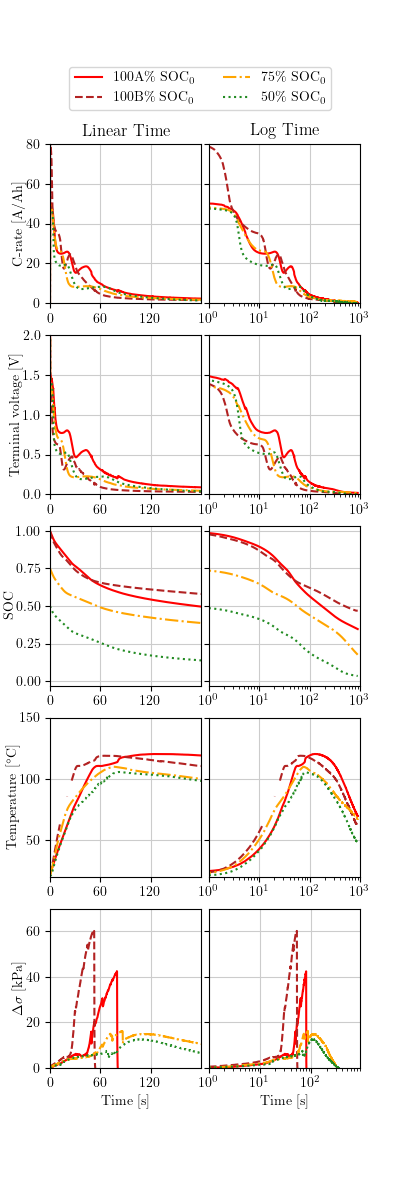

,SOC_0,SOC_f,DOD,T_max,sigma_maxs,I_0,Init_C-rate,V_0,T_tab_max,dT_max,t_vent
0,1.00,0.346496,0.653504,120.280990,42.463029,231.909857,50.415186,1.564826,114.673958,5.607032,79.8
1,1.00,0.468795,0.531205,118.821759,60.222997,371.526017,80.766525,1.494581,117.483086,1.338673,52.6
2,0.75,0.175834,0.574166,109.817425,16.179413,229.836021,49.964352,1.447498,103.279004,6.538421,-
3,0.50,0.034280,0.465720,105.569077,12.637299,226.184678,49.170582,1.704639,99.884402,5.684674,-


In [9]:
param = pybamm.ParameterValues('Tran2023')
sim_set_labels = ['SPMeTV: Average', 'SPMeTV: Fit']
fig, ax = plt.subplots(5,  2, figsize=(4, 12), gridspec_kw = {'wspace':0.05, 'hspace':0.2}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['-','--','-.',':']*2
sim_colors = ['r','firebrick','orange','forestgreen']

t_refs = [1, 1*60, 5*60]
t_refs_labels = ['1 s', '1 min', '5 min']

SOCs_0 = []
SOC_f = []
DOD = []
T_max = []
sigma_maxs = []
I_0 = []
V_0 = []
T_tab_max = []
t_vent = []

# for each cell...
for i, (SOC_name,data) in enumerate(zip (SOC_names,datas)):    
    SOC_0 = SOC_0s[SOC_name]

    # plot
    xlabel = "Time [s]"
    data_color = sim_colors[i]
    data_ls = linestyles[i]

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

    # LINEAR PLOTS
    
    ax[0,0].plot(data.t,data.I/Q_nom, label=SOC_name + "\% SOC$_0$",color = data_color, linestyle = data_ls)
    ax[0,0].set_ylabel('C-rate [A/Ah]', labelpad=0)
    ax[0,0].set_title("Linear Time") #, pad = 30
    ax[0,0].set_ylim([0,80])
    ax[0,0].set_xlim([0,60*3])
    # ax[0,0].set_xticklabels([])
    ax[0,0].grid(color='0.8')
    
    ax[1,0].plot(data.t, data.V,color = data_color, linestyle = data_ls)
    ax[1,0].set_ylabel('Terminal voltage [V]', labelpad=0)
    ax[1,0].set_ylim([0,2])
    ax[1,0].set_xlim([0,60*3])
    ax[1,0].grid(color='0.8')

    ax[3,0].plot(data.t, data.Temp,color = data_color, linestyle = data_ls)
    ax[3,0].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    ax[3,0].set_ylim([20,150])
    ax[3,0].grid(color='0.8')
    ax[3,0].set_xlim([0,60*3])

    ax[2,0].plot(data.t, data.SOC,color = data_color, linestyle = data_ls)
    ax[2,0].set_ylabel('SOC',labelpad=0)
    ax[2,0].set_ylim([-0.03,1.03])
    ax[2,0].grid(color='0.8')
    ax[2,0].set_xlim([0,60*3])

    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    ax[4,0].plot(data.t, data_sigma, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[4,0].set_ylim([0,70])
    ax[4,0].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[4,0].set_xlabel(xlabel) 
    ax[4,0].grid(color='0.8')
    ax[4,0].set_xlim([0,60*3])

    # R = data.V/data.I*1000
    # ax[5,0].plot(data.t, R, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    # ax[5,0].set_ylim([0,15])
    # ax[5,0].set_ylabel("$R_{eff}$ [m$\Omega$]",labelpad=0)
    # # ax[5,0].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
    # ax[5,0].set_xlabel(xlabel) 
    # ax[5,0].grid(color='0.8')

    # ax[5,0].plot(data.t, data.CO2, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    # ax[5,0].set_ylabel("$CO_{2}$ [ppm]",labelpad=0)
    # ax[5,0].set_ylim([400,4000])
    # ax[5,0].set_xlabel(xlabel) 
    # ax[5,0].grid(color='0.8')
    # ax[5,0].set_xlim([0,60*3])

    # LOG PLOTS
    ax[0,1].semilogx(data.t,data.I/Q_nom, label=SOC_name + "\% SOC$_0$",color = data_color, linestyle = data_ls)
    # ax[0,1].set_ylabel('C-rate', labelpad=0)
    ax[0,1].set_title("Log Time") #, pad = 30
    ax[0,1].set_ylim([0,80])
    ax[0,1].grid(color='0.8')
    ax[0,1].set_yticklabels([])
    ax[0,1].set_xlim([1,t_end])

    ax[1,1].semilogx(data.t, data.V,color = data_color, linestyle = data_ls)
    # ax[1,1].set_ylabel('Terminal voltage [V]', labelpad=0)
    ax[1,1].set_ylim([0,2])
    ax[1,1].grid(color='0.8')
    ax[1,1].set_yticklabels([])
    ax[1,1].set_xlim([1,t_end])

    ax[3,1].semilogx(data.t, data.Temp,color = data_color, linestyle = data_ls)
    # ax[2,1].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    ax[3,1].set_ylim([20,150])
    ax[3,1].grid(color='0.8')
    ax[3,1].set_yticklabels([])
    ax[3,1].set_xlim([1,t_end])

    ax[2,1].semilogx(data.t, data.SOC,color = data_color, linestyle = data_ls)
    # ax[3,1].set_ylabel('SOC',labelpad=0)
    ax[2,1].set_ylim([-0.03,1.03])
    ax[2,1].grid(color='0.8')
    ax[2,1].set_yticklabels([])
    ax[2,1].set_xlim([1,t_end])

    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    ax[4,1].semilogx(data.t, data_sigma, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[4,1].set_ylim([0,70])
    # ax[4,1].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[4,1].set_xlabel(xlabel)
    ax[4,1].grid(color='0.8')
    ax[4,1].set_yticklabels([])
    ax[4,1].set_xlim([1,t_end])

    # ax[5,1].semilogx(data.t, R, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    # ax[5,1].set_ylim([0,15])
    # ax[5,1].set_xlabel(xlabel) 
    # ax[5,1].grid(color='0.8')
    # ax[5,1].set_yticklabels([])

    # ax[5,1].semilogx(data.t, data.CO2, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    # # ax[5,1].set_ylabel("$CO_{2}$ [ppm]",labelpad=0)
    # ax[5,1].set_ylim([400,4000])
    # ax[5,1].set_xlabel(xlabel) 
    # ax[5,1].grid(color='0.8')
    # ax[5,1].set_yticklabels([])
    # ax[5,1].set_xlim([1,t_end])

    # SAVE METRICS
    SOCs_0.append(SOC_0)
    SOC_f.append(data.SOC.iloc[-1])
    DOD.append(SOC_0-data.SOC.iloc[-1])
    T_max.append(max(data.Temp))
    sigma_maxs.append(max(data_sigma))
    I_0.append(max(data.I))
    V_0.append(data.V.iloc[1])
    T_tab_max.append(max(data.T_tab))
    try: 
        t_vent.append(str(np.round(data.t.iloc[np.where(np.diff(data_sigma)<-10)[0][0]],3)))
    except:
        t_vent.append('-')


plt.setp(ax[0:6, 0], xticks=list(range(0,60*3,60)))
plt.setp(ax[0:6, 1], xticks=[1,10,100, 1000])
handles, labels = ax[0,1].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='upper center', ncol=2, prop={'size': 10},  bbox_to_anchor=(0.5, 0.95))
plt.xlim([0,t_end])
plt.tight_layout()
plt.savefig('./figs/all_ESC_data_zoom.eps', format='eps', dpi = 300)
plt.show()

metrics = {'SOC_0':SOCs_0, 'SOC_f': SOC_f, 'DOD':DOD, 'T_max': T_max, 'sigma_maxs': sigma_maxs, 'I_0':I_0, 'Init_C-rate':[i/4.6 for i in I_0],'V_0': V_0, 'T_tab_max':T_tab_max, 'dT_max':[T1 - T2 for (T1, T2) in zip(T_max,T_tab_max)], 't_vent': t_vent}
df = pd.DataFrame(metrics)
display(df)


C:\Users\Vivian\AppData\Local\Temp\ipykernel_30896\2298660882.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


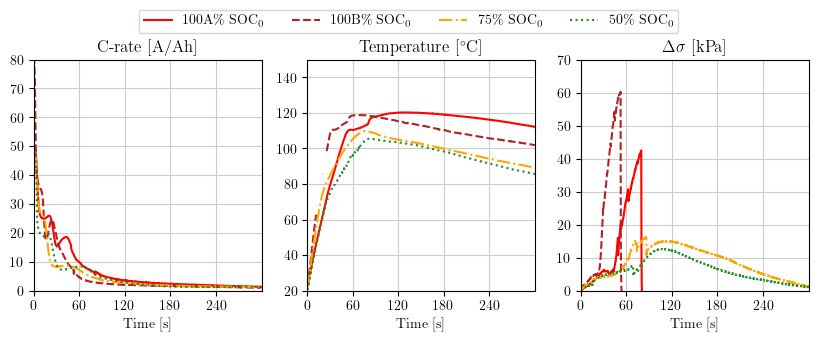

In [10]:
%matplotlib inline
param = pybamm.ParameterValues('Tran2023')
sim_set_labels = ['SPMeTV: Average', 'SPMeTV: Fit']
fig, ax = plt.subplots(1,  3, figsize=(10, 3), gridspec_kw = {'wspace':0.2, 'hspace':0.2}, constrained_layout=True)#, constrained_layout=True
ax = ax.flatten()
linestyles = ['-','--','-.',':']*2
sim_colors = ['r','firebrick','orange','forestgreen']

# t_refs = [1, 1*60, 5*60]
# t_refs_labels = ['1 s', '1 min', '5 min']

# SOCs_0 = []
# SOC_f = []
# DOD = []
# T_max = []
# sigma_maxs = []
# I_0 = []
# V_0 = []
# T_tab_max = []
# t_vent = []

# for each cell...
for i, (SOC_name,data) in enumerate(zip (SOC_names,datas)):    
    SOC_0 = SOC_0s[SOC_name]

    # plot
    xlabel = "Time [s]"
    data_color = sim_colors[i]
    data_ls = linestyles[i]

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

    # LINEAR PLOTS
    
    ax[0].plot(data.t,data.I/Q_nom, label=SOC_name + "\% SOC$_0$",color = data_color, linestyle = data_ls)
    ax[0].set_title('C-rate [A/Ah]')
    # ax[0].set_title("Linear Time") #, pad = 30
    ax[0].set_ylim([0,80])
    ax[0].set_xlim([0,60*5])
    # ax[0,0].set_xticklabels([])
    ax[0].grid(color='0.8')
    ax[0].set_xlabel(xlabel) 

    # ax[1].plot(data.t, data.V,color = data_color, linestyle = data_ls)
    # ax[1].set_ylabel('Terminal voltage [V]', labelpad=0)
    # ax[1].set_ylim([0,2])
    # ax[1].set_xlim([0,60*3])
    # ax[1].grid(color='0.8')
    # ax[1].set_xlabel(xlabel) 

    ax[1].plot(data.t, data.Temp,color = data_color, linestyle = data_ls)
    ax[1].set_title('Temperature [$^\circ$C]')
    ax[1].set_ylim([20,150])
    ax[1].grid(color='0.8')
    ax[1].set_xlim([0,60*5])
    ax[1].set_xlabel(xlabel) 

    # ax[2].plot(data.t, data.SOC,color = data_color, linestyle = data_ls)
    # ax[2].set_ylabel('SOC',labelpad=0)
    # ax[2].set_ylim([-0.03,1.03])
    # ax[2].grid(color='0.8')
    # ax[2].set_xlim([0,60*3])
    # ax[2].set_xlabel(xlabel) 

    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    ax[2].plot(data.t, data_sigma, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[2].set_ylim([0,70])
    ax[2].set_title("$\Delta \sigma$ [kPa]")
    ax[2].set_xlabel(xlabel) 
    ax[2].grid(color='0.8')
    ax[2].set_xlim([0,60*5])

    # R = data.V/data.I*1000
    # ax[5,0].plot(data.t, R, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    # ax[5,0].set_ylim([0,15])
    # ax[5,0].set_ylabel("$R_{eff}$ [m$\Omega$]",labelpad=0)
    # # ax[5,0].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
    # ax[5,0].set_xlabel(xlabel) 
    # ax[5,0].grid(color='0.8')

    # ax[5,0].plot(data.t, data.CO2, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    # ax[5,0].set_ylabel("$CO_{2}$ [ppm]",labelpad=0)
    # ax[5,0].set_ylim([400,4000])
    # ax[5,0].set_xlabel(xlabel) 
    # ax[5,0].grid(color='0.8')
    # ax[5,0].set_xlim([0,60*3])

    # # LOG PLOTS
    # ax[0,1].semilogx(data.t,data.I/Q_nom, label=SOC_name + "\% SOC$_0$",color = data_color, linestyle = data_ls)
    # # ax[0,1].set_ylabel('C-rate', labelpad=0)
    # ax[0,1].set_title("Log Time") #, pad = 30
    # ax[0,1].set_ylim([0,80])
    # ax[0,1].grid(color='0.8')
    # ax[0,1].set_yticklabels([])
    # ax[0,1].set_xlim([1,t_end])

    # ax[1,1].semilogx(data.t, data.V,color = data_color, linestyle = data_ls)
    # # ax[1,1].set_ylabel('Terminal voltage [V]', labelpad=0)
    # ax[1,1].set_ylim([0,2])
    # ax[1,1].grid(color='0.8')
    # ax[1,1].set_yticklabels([])
    # ax[1,1].set_xlim([1,t_end])

    # ax[3,1].semilogx(data.t, data.Temp,color = data_color, linestyle = data_ls)
    # # ax[2,1].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    # ax[3,1].set_ylim([20,150])
    # ax[3,1].grid(color='0.8')
    # ax[3,1].set_yticklabels([])
    # ax[3,1].set_xlim([1,t_end])

    # ax[2,1].semilogx(data.t, data.SOC,color = data_color, linestyle = data_ls)
    # # ax[3,1].set_ylabel('SOC',labelpad=0)
    # ax[2,1].set_ylim([-0.03,1.03])
    # ax[2,1].grid(color='0.8')
    # ax[2,1].set_yticklabels([])
    # ax[2,1].set_xlim([1,t_end])

    # sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    # ax[4,1].semilogx(data.t, data_sigma, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    # ax[4,1].set_ylim([0,70])
    # # ax[4,1].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    # ax[4,1].set_xlabel(xlabel)
    # ax[4,1].grid(color='0.8')
    # ax[4,1].set_yticklabels([])
    # ax[4,1].set_xlim([1,t_end])

    # ax[5,1].semilogx(data.t, R, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    # ax[5,1].set_ylim([0,15])
    # ax[5,1].set_xlabel(xlabel) 
    # ax[5,1].grid(color='0.8')
    # ax[5,1].set_yticklabels([])

    # ax[5,1].semilogx(data.t, data.CO2, color = data_color, linestyle = data_ls) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    # # ax[5,1].set_ylabel("$CO_{2}$ [ppm]",labelpad=0)
    # ax[5,1].set_ylim([400,4000])
    # ax[5,1].set_xlabel(xlabel) 
    # ax[5,1].grid(color='0.8')
    # ax[5,1].set_yticklabels([])
    # ax[5,1].set_xlim([1,t_end])

    # # SAVE METRICS
    # SOCs_0.append(SOC_0)
    # SOC_f.append(data.SOC.iloc[-1])
    # DOD.append(SOC_0-data.SOC.iloc[-1])
    # T_max.append(max(data.Temp))
    # sigma_maxs.append(max(data_sigma))
    # I_0.append(max(data.I))
    # V_0.append(data.V.iloc[1])
    # T_tab_max.append(max(data.T_tab))
    # try: 
    #     t_vent.append(str(np.round(data.t.iloc[np.where(np.diff(data_sigma)<-10)[0][0]],3)))
    # except:
    #     t_vent.append('-')


plt.setp(ax, xticks=list(range(0,60*5,60)))
# plt.setp(ax[0:6, 1] , xticks=[1,10,100, 1000])
handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='upper center', ncol=4, prop={'size': 10},  bbox_to_anchor=(0.5, 1.07))
# plt.xlim([0,t_end])
plt.tight_layout()
plt.savefig('./figs/all_ESC_data_linear_horizontal.png', format='png', dpi = 300)
plt.show()

# metrics = {'SOC_0':SOCs_0, 'SOC_f': SOC_f, 'DOD':DOD, 'T_max': T_max, 'sigma_maxs': sigma_maxs, 'I_0':I_0, 'Init_C-rate':[i/4.6 for i in I_0],'V_0': V_0, 'T_tab_max':T_tab_max, 'dT_max':[T1 - T2 for (T1, T2) in zip(T_max,T_tab_max)], 't_vent': t_vent}
# df = pd.DataFrame(metrics)
# display(df)

# COPY TO CLIPBOARD FOR PPT